In [17]:
import os
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_ollama import ChatOllama
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, RemoveMessage
from typing import Literal
from dotenv import load_dotenv
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver
load_dotenv()
api_key = os.getenv("API_KEY")


In [8]:
chat = ChatOllama(
    model="gpt-oss:120b",
    temperature=0.7,
    base_url="https://ollama.com",
    client_kwargs={
        "headers": {
            "Authorization": f"Bearer {api_key}"
        }
    }
)

In [9]:
class State(MessagesState):
    summary: str

In [10]:
def ask_question(state: State) -> State:
    
    print(f"\n-------> ENTERING ask_question:")
    
    question = "What is your question?"
    print(question)
    
    return State(messages = [AIMessage(question), HumanMessage(input())])

In [11]:
def chatbot(state: State) -> State:
    
    print(f"\n-------> ENTERING chatbot:")
        
    system_message = f'''
    Here's a quick summary of what's been discussed so far:
    {state.get("summary", "")}
    
    Keep this in mind as you answer the next question.
    '''
    
    response = chat.invoke([SystemMessage(system_message)] + state["messages"])
    response.pretty_print()
    
    return State(messages = [response])

In [12]:
def summarize_messages(state: State) -> State:
    print(f"\n-------> ENTERING summarize_messages:")

    new_conversation = ""
    for i in state["messages"]:
        new_conversation += f"{i.type}: {i.content}\n\n"
    
    summary_instructions = f'''
Update the ongoing summary by incorporating the new lines of conversation below. 
Build upon the previous summary rather than repeating it, 
so that the result reflects the most recent context and developments.
Respond only with the summary.

Previous Summary:
{state.get("summary", "")}

New Conversation:
{new_conversation}
'''

    print(summary_instructions)

    summary = chat.invoke([HumanMessage(summary_instructions)])
    
    remove_messages = [RemoveMessage(id = i.id) for i in state["messages"][:]]

    return State(messages = remove_messages, summary = summary.content)

In [13]:
graph = StateGraph(State)

In [14]:
graph.add_node("ask_question", ask_question)
graph.add_node("chatbot", chatbot)
graph.add_node("summarize_messages", summarize_messages)

graph.add_edge(START, "ask_question")
graph.add_edge("ask_question", "chatbot")
graph.add_edge("chatbot", "summarize_messages")
graph.add_edge("summarize_messages", END)

In [18]:
db_path = "LangGraph_DB/langgraph.db"
con = sqlite3.connect(database = db_path, check_same_thread = False)

In [19]:
checkpointer = SqliteSaver(con)

In [20]:
graph_compiled = graph.compile(checkpointer)

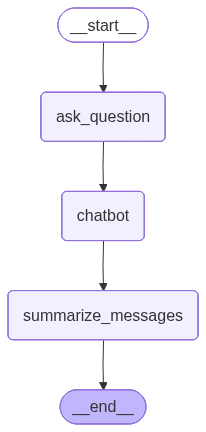

In [21]:
graph_compiled

In [22]:
config1 = {"configurable": {"thread_id": "1"}}

In [24]:
graph_compiled.invoke(State(), config1)


-------> ENTERING ask_question:
What is your question?

-------> ENTERING chatbot:
================================== Ai Message ==================================

Robin Sharma was born in Uganda in 1964.

-------> ENTERING summarize_messages:

Update the ongoing summary by incorporating the new lines of conversation below. 
Build upon the previous summary rather than repeating it, 
so that the result reflects the most recent context and developments.
Respond only with the summary.

Previous Summary:
Robin Sharma is a Canadian‑born author, speaker, and leadership coach known for best‑selling personal‑development books such as *The Monk Who Sold His Ferrari*, *The Leader Who Had No Title*, and *The 5 AM Club*. Born in Uganda in 1964 and later based in Dubai, he left a legal career in the late 1990s to focus on writing, seminars, and online coaching. His core philosophy emphasizes personal mastery, a structured morning routine (the “20/20/20” formula), storytelling through fables, lead

{'messages': [],
 'summary': 'The latest exchange clarified a basic biographical point: when asked where Robin\u202fSharma was born, the response confirmed that he was born in Uganda in 1964, reinforcing the birthplace detail already noted in his profile.'}